### Case 3.2: Classification Model Comparison and Ensemble Methods - Employee Attrition

### Context:
McCurr Healthcare Consultancy is an MNC that has thousands of employees spread out across the globe. The company believes in hiring the best talent available and retaining them for as long as possible. A huge amount of resources is spent on retaining existing employees through various initiatives. The Head of People Operations wants to bring down the cost of retaining employees. For this, he proposes limiting the incentives to only those employees who are at risk of attrition. As a recently hired Data Scientist in the People Operations Department, you have been asked to identify patterns in characteristics of employees who leave the organization. Also, you have to use this information to predict if an employee is at risk of attrition. This information will be used to target them with incentives.

### Objective :

* To identify the different factors that drive attrition
* To make a model to predict if an employee will attrite or not


### Dataset :
The data contains demographic details, work-related metrics and attrition flag.

* **EmployeeNumber** - Employee Identifier
* **Attrition** - Did the employee attrite?
* **Age** - Age of the employee
* **BusinessTravel** - Travel commitments for the job
* **DailyRate** - Data description not available**
* **Department** - Employee Department
* **DistanceFromHome** - Distance from work to home (in km)
* **Education** - 1-Below College, 2-College, 3-Bachelor, 4-Master,5-Doctor
* **EducationField** - Field of Education
* **EnvironmentSatisfaction** - 1-Low, 2-Medium, 3-High, 4-Very High
* **Gender** - Employee's gender
* **HourlyRate** - Data description not available**
* **JobInvolvement** - 1-Low, 2-Medium, 3-High, 4-Very High
* **JobLevel** - Level of job (1 to 5)
* **JobRole** - Job Roles
* **JobSatisfaction** - 1-Low, 2-Medium, 3-High, 4-Very High
* **MaritalStatus** - Marital Status
* **MonthlyIncome** - Monthly Salary
* **MonthlyRate** - Data description not available**
* **NumCompaniesWorked** - Number of companies worked at
* **Over18** - Over 18 years of age?
* **OverTime** - Overtime?
* **PercentSalaryHike** - The percentage increase in salary last year
* **PerformanceRating** - 1-Low, 2-Good, 3-Excellent, 4-Outstanding
* **RelationshipSatisfaction** - 1-Low, 2-Medium, 3-High, 4-Very High
* **StandardHours** - Standard Hours
* **StockOptionLevel** - Stock Option Level
* **TotalWorkingYears** - Total years worked
* **TrainingTimesLastYear** - Number of training attended last year
* **WorkLifeBalance** - 1-Low, 2-Good, 3-Excellent, 4-Outstanding
* **YearsAtCompany** - Years at Company
* **YearsInCurrentRole** - Years in the current role
* **YearsSinceLastPromotion** - Years since the last promotion
* **YearsWithCurrManager** - Years with the current manager

** In the real world, you will not find definitions for some of your variables. It is a part of the analysis to figure out what they might mean.

### Import the necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#to scale the data using z-score
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

#algorithms to use
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

#Metrics to evaluate the model
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve, make_scorer

#for tuning the model
from sklearn.model_selection import GridSearchCV

#to ignore warnings
import warnings
warnings.filterwarnings("ignore")

### Read the dataset

In [2]:
import requests
from io import StringIO

orig_url="https://drive.google.com/file/d/1rlNfgsTozSicELfGmfHx_G2DIkiES1A8/view?usp=sharing"

file_id = orig_url.split('/')[-2]
dwn_url='https://drive.google.com/uc?export=download&id=' + file_id
url = requests.get(dwn_url).text
csv_raw = StringIO(url)
df = pd.read_csv(csv_raw)


In [3]:
df.head()

,EmployeeNumber,Attrition,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,Yes,41,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,...,1,80,0,8,0,1,6,4,0,5
1,2,No,49,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,...,4,80,1,10,3,3,10,7,1,7
2,3,Yes,37,Travel_Rarely,1373,Research & Development,2,2,Other,4,...,2,80,0,7,3,3,0,0,0,0
3,4,No,33,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,...,3,80,0,8,3,3,8,7,3,0
4,5,No,27,Travel_Rarely,591,Research & Development,2,1,Medical,1,...,4,80,1,6,3,3,2,2,2,2


**Note that the exploratory data analysis is ommited for parsimony. A complete analysis should include this section in addition to an analysis of important features based on examination of coefficients in logistic regression and informative attributes in tree induction. Please do not use this notebook as a sample case for your project.**

## Model Building - Approach
1. Prepare data for modeling
2. Partition the data into train and test set.
3. Build model on the train data.
4. Tune the model if required.
5. Test the data on test set.

###  Preparing data for modeling

**Creating dummy variables for categorical Variables**

In [4]:
# drop Over18 -- all Y
df=df.drop(columns = ['Over18'])

#creating list of dummy columns
to_get_dummies_for = ['BusinessTravel', 'Department','Education', 'EducationField','EnvironmentSatisfaction', 'Gender',  'JobInvolvement','JobLevel', 'JobRole', 'MaritalStatus' ]

#creating dummy variables
df = pd.get_dummies(data = df, columns= to_get_dummies_for, drop_first= True)

#mapping overtime and attrition
dict_OverTime = {'Yes': 1, 'No':0}
dict_attrition = {'Yes': 1, 'No': 0}

df['OverTime'] = df.OverTime.map(dict_OverTime)
df['Attrition'] = df.Attrition.map(dict_attrition)

**Separating the independent variables (X) and the dependent variable (Y)**

In [5]:
#Separating target variable and other variables
y = df['Attrition']
X = df.drop(columns = ['Attrition'])

### Scaling the data

The independent variables in this dataset have different scales. When features have differing scales from each other, there is a chance that a higher weightage will be given to features which have a higher magnitude, and they will dominate over other features whose magnitude changes may be smaller but whose percentage changes may be just as significant or even larger. This will impact the performance of our machine learning algorithm, and we do not want our algorithm to be biased towards one feature.

The solution to this issue is **Feature Scaling**, i.e. scaling the dataset so as to give every transformed variable a comparable scale.

In this problem, we will use the **Standard Scaler** method, which centers and scales the dataset using the Z-Score.

It standardizes features by subtracting the mean and scaling it to have unit variance.

The standard score of a sample x is calculated as:

**z = (x - u) / s**

where **u** is the mean of the training samples (zero) and **s** is the standard deviation of the training samples.

In [6]:
#Scaling the data
sc=StandardScaler()
X_scaled=sc.fit_transform(X)
X_scaled=pd.DataFrame(X_scaled, columns=X.columns)

### Splitting the data into 70% train and 30% test set

Some classification problems can exhibit a large imbalance in the distribution of the target classes: for instance there could be several times more negative samples than positive samples. In such cases it is recommended to use the **stratified sampling** technique to ensure that relative class frequencies are approximately preserved in each train and validation fold.

In [7]:
#splitting the data
X_train,X_test,y_train,y_test=train_test_split(X_scaled,y,test_size=0.3,random_state=1,stratify=y)

### Model evaluation criterion

#### The model can make two types of wrong predictions:
1. Predicting an employee will attrite when the employee doesn't attrite
2. Predicting an employee will not attrite and the employee actually attrites

#### Which case is more important?
* **Predicting that the employee will not attrite but the employee attrites** i.e. losing out on a valuable employee or asset. This would be considered a major miss for any employee attrition predictor, and is hence the more important case of wrong predictions.

#### How to reduce this loss i.e the need to reduce False Negatives?
* **The company would want the Recall to be maximized**, the greater the Recall, the higher the chances of minimizing false negatives. Hence, the focus should be on increasing Recall (minimizing the false negatives) or in other words identifying the true positives (i.e. Class 1) very well, so that the company can provide incentives to control attrition rate especially for top-performers. This would help in optimizing the overall project cost towards retaining the best talent.

Also, let's create a function to calculate and print the classification report and confusion matrix so that we don't have to rewrite the same code repeatedly for each model.

In [8]:
#creating metric function
def metrics_score(actual, predicted):
    print(classification_report(actual, predicted))
    cm = confusion_matrix(actual, predicted)
    plt.figure(figsize=(8,5))
    sns.heatmap(cm, annot=True,  fmt='.2f', xticklabels=['Not Attrite', 'Attrite'], yticklabels=['Not Attrite', 'Attrite'])
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

**Reading the confusion matrix (clockwise):**

* True Negative (Actual=0, Predicted=0): Model predicts that an employee would not attrite and the employee does not attrite

* False Positive (Actual=0, Predicted=1): Model predicts that an employee would attrite but the employee does not attrite

* False Negative (Actual=1, Predicted=0): Model predicts that an employee would not attrite but the employee attrites

* True Positive (Actual=1, Predicted=1): Model predicts that an employee would attrite and the employee actually attrites

## Building the models

### We will be building 7 different models:
- ### **Tree Induction**
- ### **Logistic Regression**
- ### **Linear Discriminant Analysis (LDA)**
- ### **Quadratic Discriminant Analysis (QDA)**
- ### **K Nearest Neighbors (KNN)**
- ### **Support Vector Machines (SVM)**
- ### **Random Forest**

### **Tree Induction**

**What is Tree Induction?**
- Tree induction builds a **decision tree** model for **classification** or **regression** by learning decision rules from data.
- A **decision tree** uses nodes for decision rules, branches for outcomes, and leaves for predictions.

**How It Works:**
1. **Start with the Root Node:** Represents the entire dataset, splitting it into smaller, more homogeneous groups.
2. **Select the Best Split:** Uses criteria like **Gini impurity** or **information gain** to find the feature that best separates the data.
3. **Create Branches and Nodes:** Repeats the splitting process until stopping criteria are met (e.g., max depth).
4. **Reach Leaf Nodes:** Represents final predictions, either class labels (classification) or averages (regression).
5. **Pruning (Optional):** Simplifies the tree by removing branches, reducing **overfitting**.

**When to Use:**
- Ideal for **classification**, **regression**, and when **interpretability** or handling **non-linear relationships** is crucial.

**Strengths:**
- **Intuitive and easy to visualize.**
- **Handles non-linear relationships** without extensive preprocessing.
- **Supports categorical and numerical data** without needing scaling.

**Limitations:**
- **Prone to overfitting** if too complex.
- **Sensitive to small changes** in the data.
- **Greedy algorithm** may not always find the optimal solution.

**Example in Python:**
```python
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=3)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)
```

**Takeaway:**
- Tree induction is versatile and easy to interpret but requires careful tuning to generalize well.

In [9]:
# Instantiate a DecisionTreeClassifier 'dt' with a maximum depth of 8
dt = DecisionTreeClassifier(max_depth=8, random_state=42)

In [10]:
# Fit dt to the training set
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=8, random_state=42)

**Checking Model Performance**

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1726
           1       0.97      0.71      0.82       332

    accuracy                           0.95      2058
   macro avg       0.96      0.85      0.89      2058
weighted avg       0.95      0.95      0.95      2058



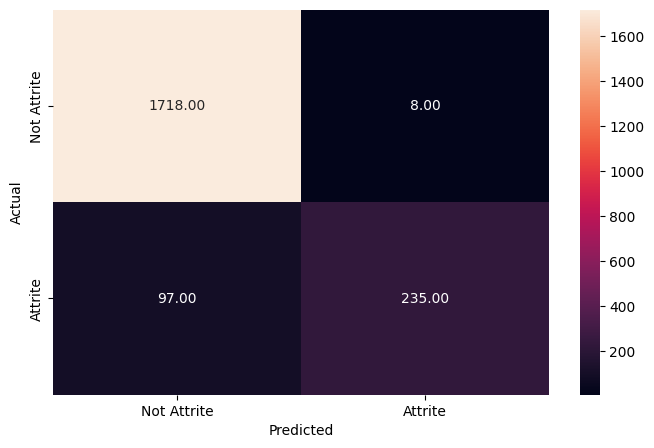

In [11]:
#checking model performace of dt
y_pred_train_dt = dt.predict(X_train)
metrics_score(y_train, y_pred_train_dt)

              precision    recall  f1-score   support

           0       0.91      0.96      0.94       740
           1       0.74      0.51      0.61       142

    accuracy                           0.89       882
   macro avg       0.82      0.74      0.77       882
weighted avg       0.88      0.89      0.88       882



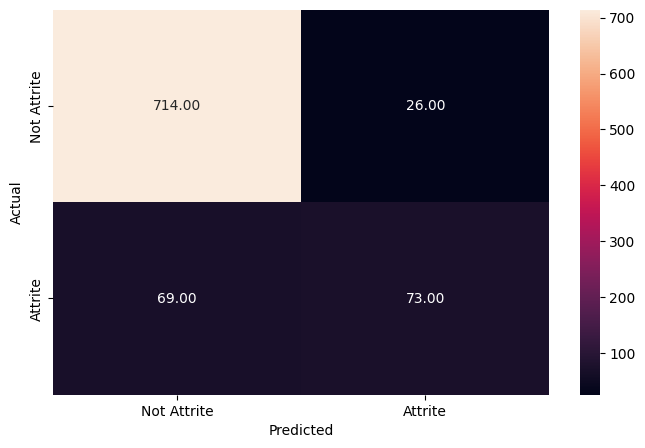

In [12]:
#checking model performace of dt
y_pred_test_dt = dt.predict(X_test)
metrics_score(y_test, y_pred_test_dt)

- The reported average includes the macro average which averages the unweighted mean per label, and the weighted average i.e. averaging the support-weighted mean per label.
- In classification, the class of interest is considered the positive class. Here, the class of interest is 1 i.e. identifying the employees at risk of attrition.


**Observations:**
- The model is performing well in terms of accuracy.
- The recall for class 1 is quite low (```54%```), which implies that this model will not perform well in differentiating out the employees who have a high chance of leaving the company, and hence this model would not help reduce the attrition rate.
- The model also has a somewhat low precision (```69%```). A precision of ~0.70 suggests that there is a 30% (1 - 0.70) chance that the model will predict that a person is going to leave even though he/she would not, and the company would waste their time and energy on these employees who are not at risk of attrition.

## **Logistic Regression**

**What is Logistic Regression?**
- **Logistic Regression** is a **supervised learning** algorithm used for **classification**, predicting the **probability** of a binary outcome (e.g., "yes" or "no").
- It is a **linear model** well-suited for **binary classification** but can be extended to multiple classes.

---

**How Does Logistic Regression Work?**

1. **Linear Combination of Features:**
   - Calculates a **linear combination** of features:
   $$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_n x_n$$
   where $z$ is the linear function and $\beta_0, \beta_1, \ldots, \beta_n$ are coefficients.

2. **Apply the Sigmoid Function:**
   - Uses the **sigmoid function** to convert \( z \) into a **probability**:
   $$\hat{p} = \frac{1}{1 + e^{-z}}$$
   where $\hat{p}$ represents the probability of class 1.

3. **Decision Boundary:**
   - Uses a threshold (often 0.5) to classify:
     - $\hat{p} \geq 0.5$ as **class 1**.
     - $\hat{p} < 0.5$ as **class 0**.

---

**When to Use Logistic Regression?**
- Best for **binary classification**, **interpretable models**, and as a **quick baseline**.

**Strengths:**
- **Simple** and **interpretable**, with efficient training and good performance on **linearly separable data**.

**Limitations:**
- Assumes **linear relationship** and may not handle **complex patterns** or **outliers** well.

---

**Example in Python:**

```python
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
```

---

**Takeaway:**
- **Logistic Regression** is effective for binary problems and easy to interpret but less suited for complex relationships.

## **Exercise 1.a. Build and Evaluate the Logistic Regression Model**
Please complete the code to build and evaluate the logistic regression model.  

In [13]:
#fitting logistic regression model
## YOUR CODE
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)


LogisticRegression()

**Checking model performance**

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      1726
           1       0.81      0.50      0.62       332

    accuracy                           0.90      2058
   macro avg       0.86      0.74      0.78      2058
weighted avg       0.89      0.90      0.89      2058



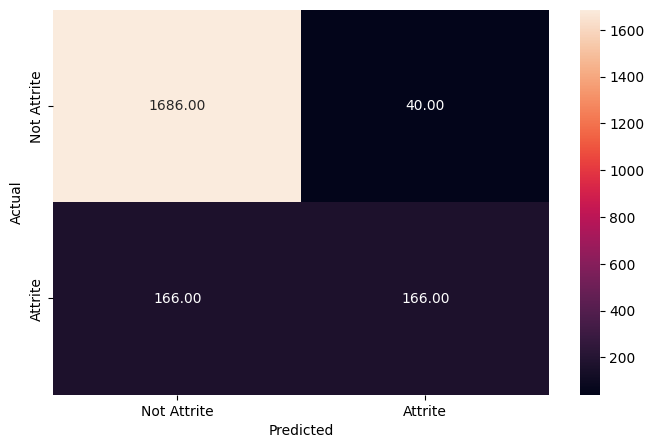

In [14]:
#checking the performance on the training data
## YOUR CODE
y_pred_train_log = log_reg.predict(X_train)
metrics_score(y_train, y_pred_train_log)

              precision    recall  f1-score   support

           0       0.90      0.97      0.94       740
           1       0.74      0.46      0.57       142

    accuracy                           0.89       882
   macro avg       0.82      0.72      0.75       882
weighted avg       0.88      0.89      0.88       882



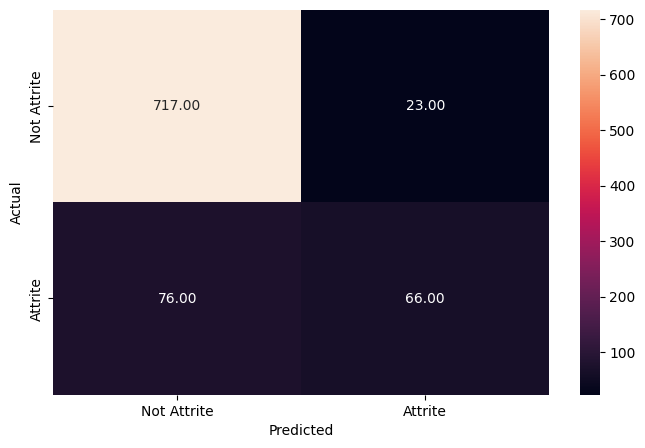

In [15]:
#checking the performance on the test dataset
## YOUR CODE
y_pred_test_log = log_reg.predict(X_test)
metrics_score(y_test, y_pred_test_log)

## **Exercise 1.b.  Performance Evaluation of Logistic Regression Model**

Please describe the performance of the logistic regression model in the context of the business scenario.

**Observations:**
The model is stable and not overfitting. The test results (89% accuracy, 0.46 recall for "Attrite") are very close to the training results (90% accuracy, 0.50 recall). This means the model's performance on new, unseen data is reliable.

The 89% accuracy is misleading. This high number is mostly due to the model's ability to correctly predict the majority "Not Attrite" class (it has a 97% recall for them). This is not the business-critical metric, as it's easy to guess that a happy employee will stay.

The model fails at its primary business goal. The Recall for the "Attrite" class (Class 1) is only 0.46 (or 46%). In the context of the business, this is a poor result. It means the model would fail to identify 54% of the employees who are actually at risk of leaving, and the company would miss the chance to give them retention incentives.

## **Linear Discriminant Analysis**

### Linear Discriminant Analysis (LDA)

**What is LDA?**
- **LDA** is a supervised algorithm for **classification** and **dimensionality reduction**, effective for **multi-class** problems.
- It finds **linear combinations** of features that maximize class separation using a **discriminant function**.

---

**How Does LDA Work?**
1. **Calculate Means:** Computes the mean of features for each class.
2. **Compute Scatter Matrices:** Measures variability within and between classes.
3. **Maximize Separation:** Finds a **linear combination** that maximizes between-class separation.
4. **Project Data:** Projects data onto the new axis to create a **linear decision boundary**.

---

**When to Use LDA?**
- **Classification** with linearly separable classes or different class means.
- **Dimensionality Reduction** for high-dimensional data.
- Suitable for **multi-class problems**.

---

**Strengths:**
- **Easy to understand**, works well with **small datasets**, and aids in **visualization**.
  
**Limitations:**
- Assumes **normality** and **linearity**, and is **sensitive to outliers**.

---

**Example in Python:**
```python
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)
y_pred = lda.predict(X_test)
```

---

**Takeaway:**
- **LDA** is ideal for separating well-defined classes and reducing dimensionality, offering a balance of **interpretability** and **performance**.

In [16]:
#fitting lda model
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

LinearDiscriminantAnalysis()

**Checking Model Performance**

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      1726
           1       0.80      0.52      0.63       332

    accuracy                           0.90      2058
   macro avg       0.85      0.74      0.78      2058
weighted avg       0.89      0.90      0.89      2058



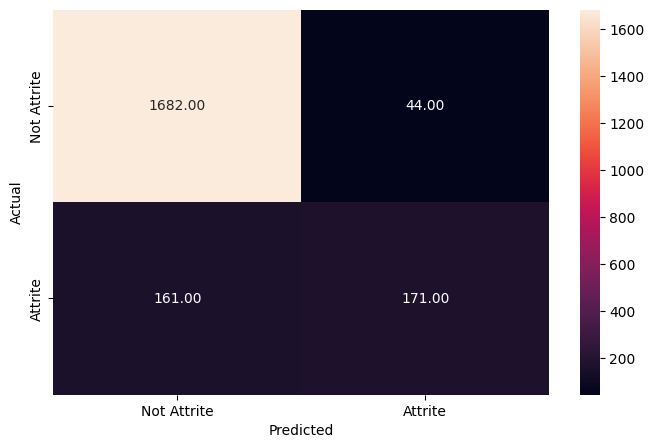

In [17]:
#checking model performace of lda
y_pred_train_lda = lda.predict(X_train)
metrics_score(y_train, y_pred_train_lda)

              precision    recall  f1-score   support

           0       0.91      0.96      0.93       740
           1       0.70      0.48      0.57       142

    accuracy                           0.88       882
   macro avg       0.80      0.72      0.75       882
weighted avg       0.87      0.88      0.87       882



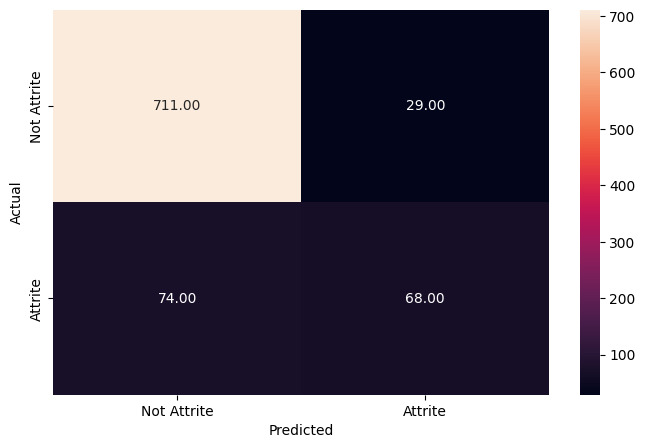

In [18]:
#checking model performace of lda
y_pred_test_lda = lda.predict(X_test)
metrics_score(y_test, y_pred_test_lda)

- The reported average includes the macro average which averages the unweighted mean per label, and the weighted average i.e. averaging the support-weighted mean per label.
- In classification, the class of interest is considered the positive class. Here, the class of interest is 1 i.e. identifying the employees at risk of attrition.


**Observations:**
- The model is performing well in terms of accuracy.
- The recall for class 1 is quite low, which implies that this model will not perform well in differentiating out the employees who have a high chance of leaving the company, and hence this model would not help reduce the attrition rate.
- The model is giving a decent average precision. A precision of ~0.70 suggests that there is a 30% (1 - 0.70) chance that the model will predict that a person is going to leave even though he/she would not, and the company would waste their time and energy on these employees who are not at risk of attrition.

## **Quadratic Discriminant Analysis (QDA)**

### Quadratic Discriminant Analysis (QDA)

**What is QDA?**
- **QDA** is a supervised classification algorithm that, like **LDA**, separates classes by modeling differences between them but allows for **each class to have its own covariance matrix**, resulting in **non-linear** decision boundaries.
- This makes QDA suitable for datasets with **complex relationships** that are not well-separated by straight lines.

---

**How Does QDA Work?**
1. **Calculate Mean and Covariance:** Computes a mean vector and covariance matrix for each class.
2. **Class-Specific Covariance:** Each class's unique covariance matrix allows for different data shapes.
3. **Bayesian Decision Rule:** Uses **Bayes' theorem** to assign classes based on the highest probability.
4. **Quadratic Boundaries:** Results in **curved decision boundaries** that adapt to complex data patterns.

---

**When to Use QDA?**
- For **non-linearly separable data** with different class distributions.
- **Multi-class classification** problems.
- When data follows a **normal distribution** but with varying covariances.

---

**Strengths:**
- **Flexible** decision boundaries for complex data.
- **Accurate** when classes have different shapes.
- Handles **multi-class** problems well.

**Limitations:**
- Requires **more data** to estimate covariance matrices accurately.
- **Sensitive to outliers** and assumes **normality** within each class.

---

**Example in Python:**

```python
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)
y_pred = qda.predict(X_test)
```

---

**Takeaway:**
- **QDA** is effective for complex class distributions but needs more data and assumes normality, making it a powerful alternative when simpler models like LDA fall short.

In [19]:
#fitting qda model
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train, y_train)

QuadraticDiscriminantAnalysis()

              precision    recall  f1-score   support

           0       1.00      0.16      0.28      1726
           1       0.19      1.00      0.31       332

    accuracy                           0.30      2058
   macro avg       0.59      0.58      0.30      2058
weighted avg       0.87      0.30      0.28      2058



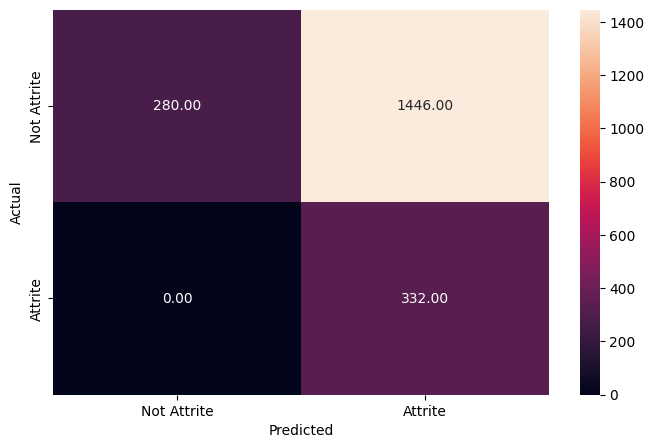

In [20]:
#checking model performance on the training data
y_pred_train_qda = qda.predict(X_train)
metrics_score(y_train, y_pred_train_qda)

              precision    recall  f1-score   support

           0       0.94      0.16      0.28       740
           1       0.18      0.94      0.30       142

    accuracy                           0.29       882
   macro avg       0.56      0.55      0.29       882
weighted avg       0.82      0.29      0.28       882



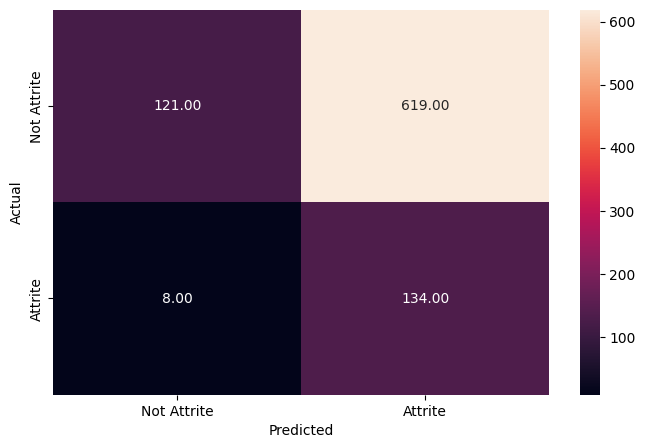

In [21]:
#checking performance of the model on the test data
y_pred_test_qda = qda.predict(X_test)
metrics_score(y_test, y_pred_test_qda)

**Observations:**

- QDA gives a very high recall for class 1 but the recall for class 0 is very poor which makes the **overall recall and accuracy very low**.
- **The model has a high number of false positives**, i.e the model will predict that the employee would leave even though he/she would not.
- This is a poor model that will be of no use to the company.

## **K- Nearest Neighbors (KNN)**

### K-Nearest Neighbors (KNN)

**What is KNN?**
- **KNN** is a simple, non-parametric supervised algorithm for **classification** and **regression**.
- It predicts by finding the **'k' nearest data points** and assigning a class or value based on their majority.

---

**How Does KNN Work?**
1. **Choose 'k'**: The number of neighbors to consider.
2. **Calculate Distances**: Measures like **Euclidean** or **Manhattan** distance determine closeness.
3. **Find Neighbors**: Identify the 'k' closest points.
4. **Assign Class**: Uses **majority voting** for classification or **averaging** for regression.

---

**Key Concepts:**
- **Choice of 'k'**: Small 'k' may overfit, large 'k' may underfit.
- **Distance Matters**: Normalizing features is essential as KNN relies on distance.
- **Lazy Learner**: KNN stores data and makes predictions when queried.

---

**Strengths:**
- **Simple** and **versatile** for both tasks.
- **No training time**, ideal for small datasets.

**Limitations:**
- **Computationally expensive** on large datasets.
- **Sensitive to scaling** and **irrelevant features**.

---

**Example in Python:**
```python
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
```

**Takeaway:**
- KNN is easy to understand, great for beginners, but requires careful feature scaling and selection of **'k'** for optimal results.

#### Determining the Optimal Number of Neighbors
We can build some code to find the best number of neighbors (**k**) for a **K-Nearest Neighbors (KNN)** model. It tests multiple values of **k** and evaluates how well each one performs. By training and validating the model multiple times for each value, it ensures that the chosen **k** is the one that consistently gives the lowest error, balancing accuracy between training and unseen data. The end result is a recommendation for the **k** that best generalizes to new data, making the model more reliable and accurate.

In [22]:
knn = KNeighborsClassifier()

# We select the best value of k for which the error rate is the least in the validation data
# Let us loop over a few values of the k to determine the best k

train_error = []
test_error = []
knn_many_split = {}

error_df_knn = pd.DataFrame()
features = X.columns

for k in range(1,15):
    train_error = []
    test_error = []
    lista = []
    knn = KNeighborsClassifier(n_neighbors=k)
    for i in range(30):
        X_train_new, X_val, y_train_new, y_val = train_test_split(X_train, y_train, test_size = 0.20)

        #Fitting knn on training data
        knn.fit(X_train_new, y_train_new)
        #Calculating error on training and validation data
        train_error.append(1 - knn.score(X_train_new, y_train_new))
        test_error.append(1 - knn.score(X_val, y_val))
    lista.append(sum(train_error)/len(train_error))
    lista.append(sum(test_error)/len(test_error))
    knn_many_split[k] = lista

#### Visualizing the Neighbor Optimization Process

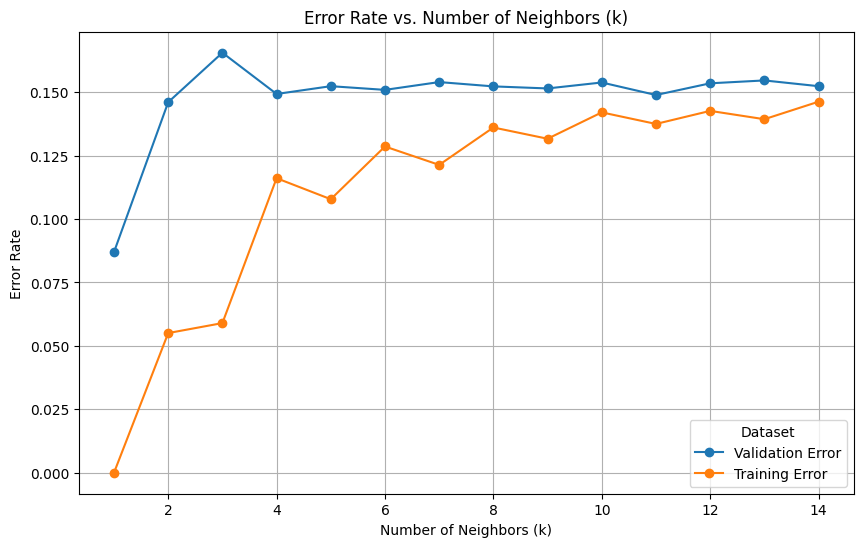

In [23]:
# Initialize lists to store k values and corresponding error rates for validation and training
kltest = []  # For storing k values for validation error
vltest = []  # For storing validation error rates
kltrain = []  # For storing k values for training error
vltrain = []  # For storing training error rates

# Extract validation error rates for each k from the knn_many_split dictionary
for k, v in knn_many_split.items():
    kltest.append(k)  # Add the current k value
    vltest.append(knn_many_split[k][1])  # Add the validation error for the current k

# Extract training error rates for each k from the knn_many_split dictionary
for k, v in knn_many_split.items():
    kltrain.append(k)  # Add the current k value
    vltrain.append(knn_many_split[k][0])  # Add the training error for the current k

# Plotting k values vs. error rates for both training and validation datasets
plt.figure(figsize=(10, 6))  # Create a figure with specified size
plt.plot(kltest, vltest, label='Validation Error', marker='o')  # Plot validation error with markers
plt.plot(kltrain, vltrain, label='Training Error', marker='o')  # Plot training error with markers

# Add title and labels to the plot for better understanding
plt.title('Error Rate vs. Number of Neighbors (k)')  # Set the title of the plot
plt.xlabel('Number of Neighbors (k)')  # Label for the x-axis, indicating different k values
plt.ylabel('Error Rate')  # Label for the y-axis, showing error rates

# Add a grid for easier visualization of the plot
plt.grid(True)  # Display a grid on the plot for better readability

# Add a legend to differentiate between the training and validation error lines
plt.legend(title='Dataset')  # Display legend with a title for clarity

# Display the final plot
plt.show()  # Render the plot


- We can see that the test error is more or less similar for K greater than or equal to 5. But the train error keeps increasing with increasing K.
- This implies that we would get a lower train and test error if we choose K = 5. Also, if we choose a high value of K, the model would be biased due to the imbalance in the dataset.
- Too small of a K value could lead to underfitting.
- So, let's fit the KNN model with **K = 5** on the entire training set.

In [24]:
#define knn model
knn=KNeighborsClassifier(n_neighbors=5)

In [25]:
#fitting data to the KNN model
knn.fit(X_train,y_train)

KNeighborsClassifier()

              precision    recall  f1-score   support

           0       0.90      0.98      0.94      1726
           1       0.82      0.45      0.58       332

    accuracy                           0.89      2058
   macro avg       0.86      0.71      0.76      2058
weighted avg       0.89      0.89      0.88      2058



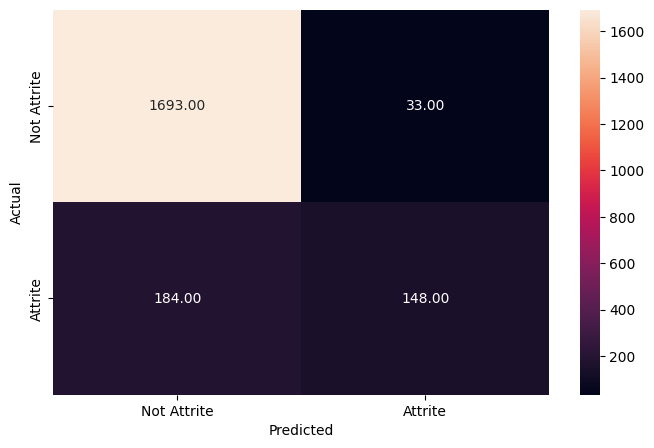

In [26]:
#checking the performance of knn model
y_pred_train_knn = knn.predict(X_train)
metrics_score(y_train, y_pred_train_knn)

              precision    recall  f1-score   support

           0       0.88      0.97      0.92       740
           1       0.67      0.29      0.40       142

    accuracy                           0.86       882
   macro avg       0.77      0.63      0.66       882
weighted avg       0.84      0.86      0.84       882



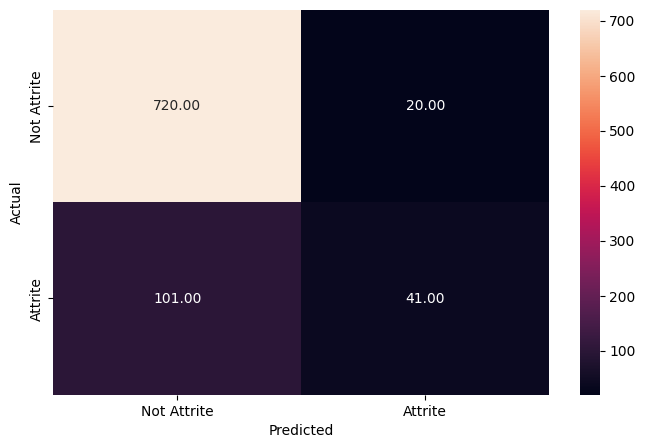

In [27]:
y_pred_test_knn = knn.predict(X_test)
metrics_score(y_test, y_pred_test_knn)

- The model gives a similar performance on the train and test data but the **recall is not very good**. Let's see if we can improve on that.

**Let's try to fine tune this model and check if we could increase the Recall.**

### Using GridSearchCV for Hyperparameter tuning model

* Hyperparameter tuning is tricky in the sense that there is no direct way to calculate how a change in the hyperparameter value will reduce the loss of your model, so we usually resort to experimentation.
* **Grid search** is a tuning technique that attempts to compute the optimum values of hyperparameters.
* It is an exhaustive search that is performed on specific parameter values of a model.
* The parameters of the estimator/model used to apply these methods are optimized by cross-validated grid-search over a parameter grid.

-> **n_neighbors**

- Number of neighbors to use by default for kneighbors queries.

-> **weights={‘uniform’, ‘distance’}**
- uniform : uniform weights. All points in each neighborhood are weighted equally.
- distance : weight points by the inverse of their distance. In this case, the closer neighbors of a query point will have a greater influence than neighbors which are further away.

-> **p**

- When p = 1, this is equivalent to using manhattan_distance (L1), and euclidean_distance (L2) is used for p = 2.


In [28]:
params_knn={'n_neighbors':np.arange(3,15),'weights':['uniform','distance'],'p':[1,2]}

grid_knn=GridSearchCV(estimator=knn,param_grid=params_knn,scoring='recall',cv=10)

model_knn=grid_knn.fit(X_train,y_train)

knn_estimator = model_knn.best_estimator_
print(knn_estimator)

KNeighborsClassifier(n_neighbors=np.int64(4), p=1, weights='distance')


- The best hyperparameters for the KNN classifier are n_neighbors=3, weights='distance', and p=1

**Let's use these parameters to build the new KNN model and find the recall of that model.**

In [29]:
#Fit the best estimator on the training data
knn_estimator.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=np.int64(4), p=1, weights='distance')

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1726
           1       1.00      1.00      1.00       332

    accuracy                           1.00      2058
   macro avg       1.00      1.00      1.00      2058
weighted avg       1.00      1.00      1.00      2058



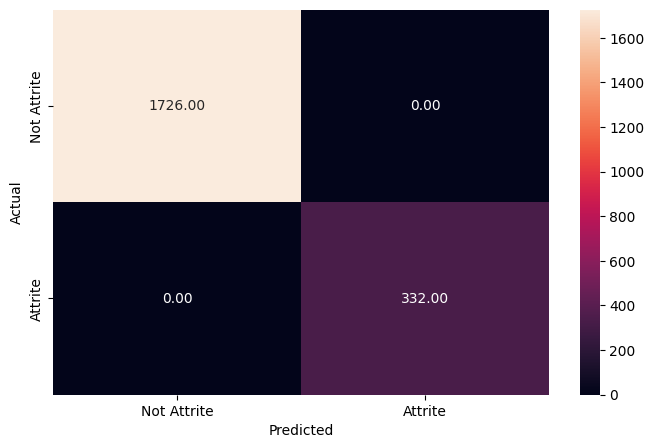

In [30]:
y_pred_train_knn_estimator = knn_estimator.predict(X_train)
metrics_score(y_train, y_pred_train_knn_estimator)

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       740
           1       0.87      0.85      0.86       142

    accuracy                           0.95       882
   macro avg       0.92      0.91      0.92       882
weighted avg       0.95      0.95      0.95       882



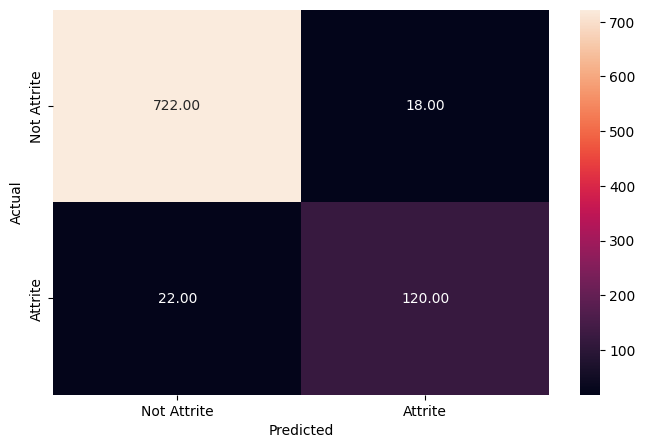

In [31]:
y_pred_test_knn_estimator = knn_estimator.predict(X_test)
metrics_score(y_test, y_pred_test_knn_estimator)

## **Exercise 2. Impacts of Hyperparameter Tuning on KNN**

Please discuss the differences in performance after adjusting the KNN model's hyperparameters using the grid search procedure.

**Observations:**
The model is overfit, but still performs well. The tuned model achieves 100% perfect scores on the training data, which means it has memorized that set. However, this overfitting does not severely hurt its ability to generalize, as it still achieves a high 95% accuracy on the unseen test data.

The model is excellent for the business goal. The most important metric for this problem is Recall for the "Attrite" class (Class 1). The tuned model has a recall of 0.85 (85%) on the test set, meaning it successfully identifies 85% of all employees who are at risk of leaving.

By tuning the hyperparameters, we found a KNN model that is vastly better at the company's primary goal: finding at-risk employees so they can be targeted with retention incentives.



## **Support Vector Machines (SVM)**

### Support Vector Machine (SVM)

**What is SVM?**
- **SVM** is a supervised algorithm for **classification** and **regression**, best known for finding the **optimal boundary** (hyperplane) that separates classes.

---

**How Does SVM Work?**
- SVM finds a **hyperplane** that divides data points into classes with the **maximum margin**, which is the distance between the hyperplane and the closest points (**support vectors**).
- A larger margin helps the model generalize better to new data.

---

**Key Concepts:**
- **Hyperplane:** A boundary separating classes.
- **Support Vectors:** Closest points to the hyperplane that influence its position.
- **Margin:** Distance between support vectors and the hyperplane, maximized by SVM.

---

**Non-Linearly Separable Data:**
- Uses the **kernel trick** to map data to higher dimensions, making it easier to separate.
  - **Linear Kernel:** For linearly separable data.
  - **Polynomial Kernel:** For complex patterns.
  - **RBF Kernel:** Commonly used for non-linear data.

---

**Strengths:**
- **Effective for high-dimensional data.**
- **Robust** with clear class margins.
- **Versatile** with various kernels.

**Limitations:**
- **Computationally intensive** with large datasets.
- **Sensitive to noise** in overlapping data.

---

**Example in Python:**

```python
from sklearn.svm import SVC

model = SVC(kernel='linear', C=1.0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
```

**Takeaway:**
- **SVM** is powerful for classification with clear margins but requires careful tuning of kernels and works best with smaller datasets.

In [32]:
#fitting qda model
svm = SVC()
svm.fit(X_train, y_train)

SVC()

              precision    recall  f1-score   support

           0       0.95      1.00      0.97      1726
           1       0.99      0.73      0.84       332

    accuracy                           0.96      2058
   macro avg       0.97      0.87      0.91      2058
weighted avg       0.96      0.96      0.95      2058



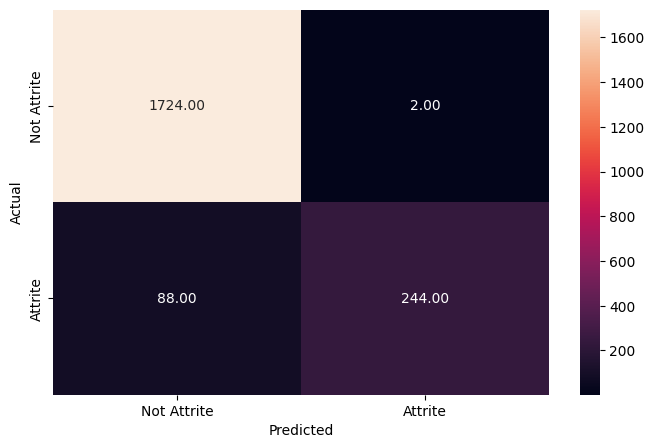

In [33]:
#checking model performance on the training data
y_pred_train_svm = svm.predict(X_train)
metrics_score(y_train, y_pred_train_svm)

              precision    recall  f1-score   support

           0       0.90      0.99      0.94       740
           1       0.88      0.46      0.60       142

    accuracy                           0.90       882
   macro avg       0.89      0.72      0.77       882
weighted avg       0.90      0.90      0.89       882



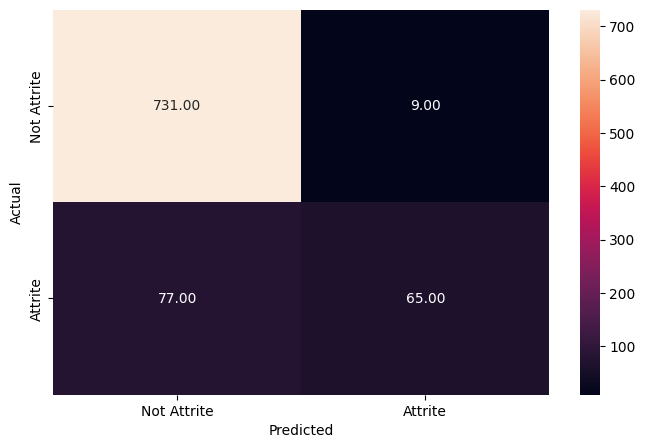

In [34]:
#checking performance of the model on the test data
y_pred_test_svm = svm.predict(X_test)
metrics_score(y_test, y_pred_test_svm)

**Observations:**.  
- The model achieves a high **overall accuracy** of **90%**, indicating strong performance in predicting the majority class.
- **Precision** for class **0** (non-attrition) is **0.90**, while for class **1** (attrition), it is **0.88**, suggesting that the model is effective at identifying non-attrition cases but slightly less precise for predicting attrition cases.
- **Recall** for class **0** is **0.99**, indicating that nearly all non-attrition cases are correctly identified. However, the **recall** for class **1** is **0.46**, showing that the model misses a significant portion of attrition cases.

## Random Forest Classifier

**What is Random Forest?**
- **Random Forest** is an ensemble learning method that combines multiple **decision trees** to improve classification or regression accuracy.
- It works by aggregating the predictions of individual trees to produce a more **robust** and **accurate** final prediction.

---

**How Does Random Forest Work?**
- **Bagging Technique:** Random Forest uses **bagging** (Bootstrap Aggregating), where each tree is trained on a **random subset** of the data.
- **Random Feature Selection:** At each split, trees consider a **random subset of features** rather than all features, adding diversity.
- **Combine Predictions:** The final output is determined by **majority voting** (for classification) or **averaging** (for regression) across all trees.

---

**Key Concepts:**
- **Bagging:** Reduces variance by training each tree on a different subset of data.
- **Random Feature Selection:** Prevents overfitting by introducing randomness into the tree-building process.
- **Ensemble Output:** Aggregates multiple trees’ predictions to improve stability and accuracy.

---

**Strengths of Random Forest:**
- **Reduces Overfitting:** By averaging multiple trees, Random Forest is less prone to overfitting compared to a single decision tree.
- **Handles Large Datasets:** It performs well with large datasets and can capture complex relationships.
- **Works with Missing Data:** Can handle missing values by averaging results across trees.

**Limitations of Random Forest:**
- **Less Interpretability:** With many trees, understanding individual decision-making becomes difficult.
- **Computationally Intensive:** Training many trees can require significant time and resources, especially with large datasets.
- **Tuning Required:** Performance depends on hyperparameters like the number of trees and the number of features considered.

---

**Example in Python:**

```python
from sklearn.ensemble import RandomForestClassifier

# Create and train a Random Forest model
rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train, y_train)

# Make predictions
y_pred = rf.predict(X_test)
```

---

**Takeaway:**
- **Random Forest** is a versatile and powerful model that combines multiple decision trees to improve accuracy and reduce overfitting.
- It is ideal for large datasets with complex relationships, but it can be computationally expensive and harder to interpret than a single decision tree.

In [35]:
#Fitting the decision tree classifier on the training datarf_estimator
rf_estimator = RandomForestClassifier(class_weight={0:0.83,1:0.17}, random_state=1)

rf_estimator.fit(X_train,y_train)

RandomForestClassifier(class_weight={0: 0.83, 1: 0.17}, random_state=1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1726
           1       1.00      1.00      1.00       332

    accuracy                           1.00      2058
   macro avg       1.00      1.00      1.00      2058
weighted avg       1.00      1.00      1.00      2058



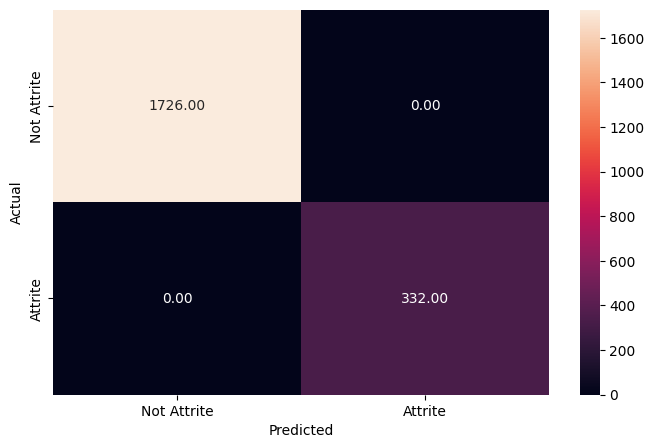

In [36]:
#Checking performance on the training data
y_pred_train_rf = rf_estimator.predict(X_train)
metrics_score(y_train, y_pred_train_rf)

              precision    recall  f1-score   support

           0       0.96      0.99      0.97       740
           1       0.94      0.78      0.85       142

    accuracy                           0.96       882
   macro avg       0.95      0.89      0.91       882
weighted avg       0.96      0.96      0.96       882



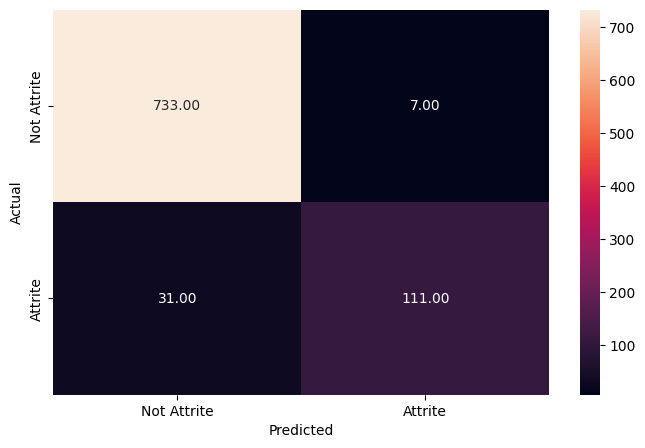

In [37]:
#Checking performance on the testing data
y_pred_test_rf = rf_estimator.predict(X_test)
metrics_score(y_test, y_pred_test_rf)

**Observations:**.  
- The model achieves an excellent **overall accuracy** of **96%**, indicating strong overall predictive performance.
- **Precision** is **0.96** for class **0** (non-attrition) and **0.94** for class **1** (attrition), suggesting that the model accurately identifies both non-attrition and attrition cases.
- **Recall** for class **0** is **0.99**, showing that nearly all non-attrition cases are correctly captured. The **recall** for class **1** is **0.78**, indicating that while the model detects most attrition cases, some are still missed.

### Overall Model Comparison
This function, `compare_model_performances`, evaluates the performance of multiple classification models using key metrics. Here’s what it does:

- **Inputs:**
  - `y_true`: The true labels of the dataset.
  - `y_preds_dict`: A dictionary where each key is a model name and each value is the corresponding model’s predicted labels.

- **Outputs:**
  - Returns a **pandas DataFrame** that contains the **accuracy**, **precision**, **recall**, and **F1 score** for each model.

- **Process:**
  - Iterates over each model's predictions in `y_preds_dict`.
  - Calculates **accuracy**, **precision**, **recall**, and **F1 score** using scikit-learn functions.
  - Stores the results for each model in a list, which is then converted into a DataFrame.

This function allows for easy comparison of different models' performances by presenting their evaluation metrics in a tabular format.

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compare_model_performances(y_true, y_preds_dict):
  """
  Compares the performance of multiple classification models.

  Args:
    y_true: True labels of the dataset.
    y_preds_dict: A dictionary where keys are model names and values are
      predicted labels for each model.

  Returns:
    A pandas DataFrame with accuracy, precision, recall, and F1 score for
      each model.
  """

  results = []
  for model_name, y_pred in y_preds_dict.items():
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    })

  return pd.DataFrame(results)

This code snippet creates a dictionary, `y_preds_dict`, containing the predicted labels from various classification models (e.g., Decision Tree, Logistic Regression, SVM). It then uses the `compare_model_performances` function to generate a DataFrame, `model_comparison_df`, which summarizes the accuracy, precision, recall, and F1 score for each model, enabling a direct comparison of their performance.

In [39]:
# Example usage (replace with your actual model predictions)
y_preds_dict = {
    'Decision Tree': y_pred_test_dt,
    'Logistic Regression': y_pred_test_log,
    'Linear Discriminant Analysis': y_pred_test_lda,
    'Quadratic Discriminant Analysis': y_pred_test_qda,
    'K-Nearest Neighbors': y_pred_test_knn,
    'Support Vector Machines': y_pred_test_svm,
    'Random Forest': y_pred_test_rf
}

model_comparison_df = compare_model_performances(y_test, y_preds_dict)
model_comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.892290,0.883783,0.892290,0.884202
1,Logistic Regression,0.887755,0.877985,0.887755,0.876819
2,Linear Discriminant Analysis,0.883220,0.872776,0.883220,0.873949
3,Quadratic Discriminant Analysis,0.289116,0.815621,0.289116,0.281856
4,K-Nearest Neighbors,0.862812,0.843999,0.862812,0.839001
5,Support Vector Machines,0.902494,0.900465,0.902494,0.889288
6,Random Forest,0.956916,0.956406,0.956916,0.955271


## **Exercise 3. Model Comparison**

**Please do a little bit of research to find out what factors about the data and/or the modeling process could be related to the poor performance of the QDA model. Summarize your findings in 3-4 sentences or bullets.**

The QDA model's poor performance (0.289 accuracy) is almost certainly due to its strict assumptions being violated by this dataset:

Non-Normal Data: QDA assumes that the features (like Age, MonthlyIncome, etc.) for each class are normally distributed (bell-shaped). Real-world employee data is almost never normal; for example, MonthlyIncome is typically highly skewed.

Multicollinearity: The dataset likely contains highly correlated features (e.g., YearsAtCompany, YearsInCurrentRole, TotalWorkingYears). QDA is highly sensitive to this, and its calculations can become unstable or "break," leading to poor results.

Data Requirement: QDA must estimate a separate, complex "shape" (covariance matrix) for each class. Since the "Attrite" class is a small minority, QDA likely doesn't have enough data to build a reliable model, while the simpler LDA (which assumes one shared shape) performs much better (0.883 accuracy).  




**What type of ensemble method is Random Forest Classification? Please describe why you think the Random Forest model performs well in this scenario. Consider the features of the data and the nature of the Random Forest Classification
procedure.**

**What type of ensemble method:** Random Forest is a "bagging" (Bootstrap Aggregating) ensemble method. It works by building a large "forest" of individual decision trees, where each tree is trained on a different random sample of the data and a different random subset of the features. The final prediction is a "majority vote" from all the trees in the forest.

**Why it performs well in this scenario:**

Reduces Overfitting: A single decision tree tends to overfit the training data. By averaging the "votes" of hundreds of diverse trees, Random Forest cancels out this individual noise and generalizes much better to new, unseen data. This is why its accuracy (0.956) is significantly higher than the single Decision Tree's (0.892).

Handles Correlated Features: This dataset has many features that are likely correlated (like the various "Years" columns). Random Forest excels at this because it forces each tree to use only a random subset of features. This prevents the model from relying too heavily on any one feature and helps it discover more robust and complex patterns.

Captures Non-Linearity: The decision to leave a company is complex and non-linear. A Random Forest, being made of many deep trees, is excellent at capturing these complex interactions (e.g., "high DistanceFromHome only matters if JobRole is not 'Manager'") without overfitting like a single tree would.

    


### Voting Classfier
A **voting classifier** is a technique in ensemble learning that combines the predictions from multiple individual models to improve the overall accuracy and robustness of the final prediction. The basic idea is that by aggregating the decisions of several models, the ensemble can make better predictions than any single model on its own.

Here's how it works:
- The voting classifier takes the predictions from several different models and combines them to make a final decision.
- It can do this in two main ways:
  - **Hard Voting**: Each model casts a "vote" for a specific class, and the class that receives the majority of votes is chosen as the final prediction.
  - **Soft Voting**: Instead of just considering the class prediction, this approach averages the probability estimates from each model for every possible class. The class with the highest average probability becomes the final prediction.

By using multiple models, the voting classifier can balance out the weaknesses of individual models, resulting in a more accurate and stable prediction overall. This method is particularly useful when different models have varied strengths and work well with different aspects of the data.

              precision    recall  f1-score   support

           0       0.94      0.99      0.96       740
           1       0.90      0.65      0.76       142

    accuracy                           0.93       882
   macro avg       0.92      0.82      0.86       882
weighted avg       0.93      0.93      0.93       882



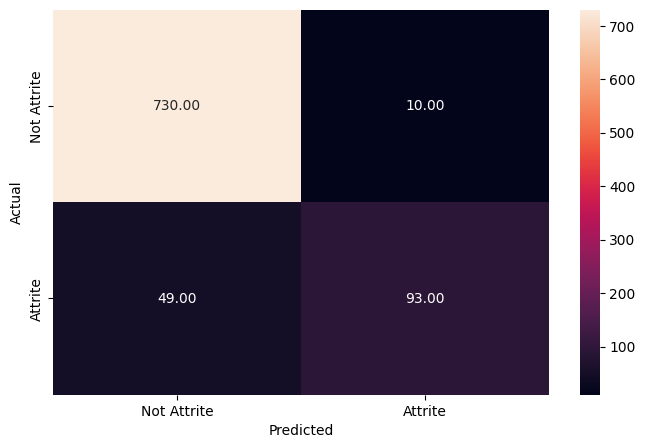

In [42]:
from sklearn.ensemble import VotingClassifier

# Select three models to compare
# - knn_estimator
# - svm
# - lg # Logistic Regression

# Create a voting classifier with the selected models
# Set probability=True in SVC to enable predict_proba
svm = SVC(probability=True)

voting_clf = VotingClassifier(estimators=[
    ('knn', knn_estimator),
    ('svm', svm),
    ('lr', log_reg)
], voting='soft')  # You can change 'soft' to 'hard' depending on your preference

# Train the voting classifier
voting_clf.fit(X_train, y_train)

# Make predictions using the voting classifier
y_pred_voting = voting_clf.predict(X_test)

# Evaluate the voting classifier
metrics_score(y_test, y_pred_voting)

**Observations:**
- The model achieves a strong **overall accuracy** of **93%**, indicating it can correctly classify most cases.
- **Precision** is **0.94** for class **0** (non-attrition) and **0.90** for class **1** (attrition), suggesting that the model is effective at identifying both categories but slightly more accurate for non-attrition.
- **Recall** for class **0** is **0.99**, meaning nearly all non-attrition cases are detected. However, the **recall** for class **1** is **0.65**, indicating that some attrition cases are missed by the model.


## **Exercise 4.a. Voting Classifier with Different Models**

Select a different subset of three models and repeat the voting classifier process above with the new models. See if you can improve the overall performance.



              precision    recall  f1-score   support

           0       0.92      0.98      0.95       740
           1       0.86      0.55      0.67       142

    accuracy                           0.91       882
   macro avg       0.89      0.77      0.81       882
weighted avg       0.91      0.91      0.90       882



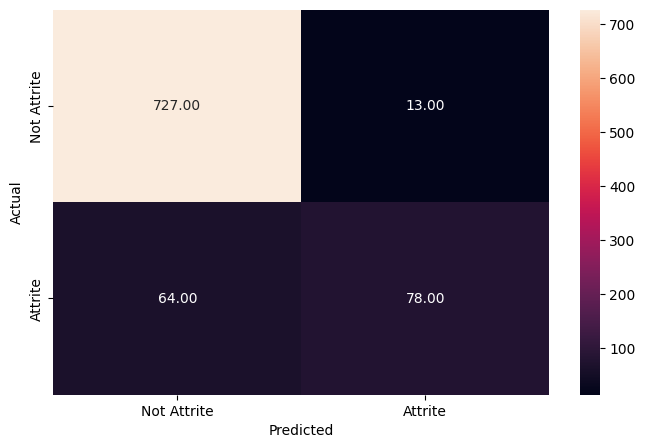

In [44]:
from sklearn.ensemble import VotingClassifier

# Select three models to compare
# -Decision Tree
# -Linear Discriminant Analysis
# -Random Forest

# Create a voting classifier with the selected models
# Set probability=True in SVC to enable predict_proba
svm = SVC(probability=True)
voting_clf1 = VotingClassifier(estimators=[
    ('dt', dt),
    ('lda', lda),
    ('rf', rf_estimator)
], voting='soft')

# Train the voting classifier
voting_clf1.fit(X_train, y_train)

# Make predictions using the voting classifier
y_pred_voting1 = voting_clf1.predict(X_test)

# Evaluate the voting classifier
metrics_score(y_test, y_pred_voting1)

## **Exercise 4.b. Voting Classifier with Different Models Observations**

**Please summarize the results of the voting classifier with different models.**
The model has very high precision. With a precision of 0.86 for the "Attrite" class, this model is highly reliable. This means 86% of the employees it flags as "at risk" are actually at-risk, so the company would waste very few retention incentives (only 13 False Positives).

The model's recall is mediocre. It achieved a recall of 0.55, meaning it successfully identified only 55% of the employees who actually attrited. This is better than the baseline Logistic Regression model (46%) but is a major step down from the tuned KNN's performance (85%).

The ensemble is not the best model. The "soft" voting (averaging probabilities) from the Decision Tree, LDA, and Random Forest resulted in a lower recall. This suggests the (likely) weaker performance of the DT and LDA models diluted the strength of the Random Forest

*Responses will vary.*

## **Exercise 5. Conclusions**

We have tried multiple models with a focus on identifying the best performing model according to the metrics of interest.

- What model performance metrics should the company optimize and why? (please explain in the context of the business scenario).
    The company must optimize for Recall (True Positive Rate) for the "Attrite" class. The business goal is to find all at-risk employees to prevent them from leaving, making a False Negative (missing an at-risk employee) the most expensive error. Precision is a secondary goal to ensure the cost of retention incentives is not wasted on employees who were never going to leave.
---
- Which model is the best performing according to the metrics of interest for the company?   
    Random Forest is the best model by a large margin. It has the highest Accuracy (0.957), Precision (0.956), and F1 Score (0.955).Most importantly, Random Forest has the highest Recall (0.957). In the context of the employee attrition problem, this means it's the most effective model at achieving the primary goal: finding the highest percentage (95.7%) of employees who are actually at risk of leaving.
---
- What additional techniques could be utilized in order to achieve a better performing model?   
    To improve further, we could use more advanced ensemble methods like XGBoost or Gradient Boosting, which are powerful at learning complex patterns. Applying hyperparameter tunnin to ranfom forest or ensambled model can also lead to better perfomrning model.
---
   
- How should the business utilize the selected model to identify likely attrition cases?   
    The business should use the Random Forest model by running it on their entire database of current employees. This will generate a prioritized list of all staff, ranked by their risk of attrition. HR managers must then use this list to proactively engage the employees at the top (the highest-risk cases) with targeted retention incentives, career discussions, and other support to prevent them from leaving.  

---    

### **(Optional) Hyperparameter Tuning the Random Forest**
#### Uncomment to run code -- runtime can be very long

**n_estimators**: The number of trees in the forest.

**min_samples_split**: The minimum number of samples required to split an internal node:

**min_samples_leaf**: The minimum number of samples required to be at a leaf node.

**max_features{“auto”, “sqrt”, “log2”, 'None'}**: The number of features to consider when looking for the best split.

- If “auto”, then max_features=sqrt(n_features).

- If “sqrt”, then max_features=sqrt(n_features) (same as “auto”).

- If “log2”, then max_features=log2(n_features).

- If None, then max_features=n_features.

In [45]:
# # Choose the type of classifier.
rf_estimator_tuned = RandomForestClassifier(class_weight={0:0.83,1:0.17}, random_state=1)

# # Grid of parameters to choose from
# ## add from article
params_rf = {
        "n_estimators": [100,250,500],
        "min_samples_leaf": np.arange(1, 4,1),
        "max_features": [0.7,0.9,'auto'],
}

# # Type of scoring used to compare parameter combinations - recall score for class 1
scorer = make_scorer(recall_score, pos_label=1)

# # Run the grid search
grid_obj = GridSearchCV(rf_estimator_tuned, params_rf, scoring=scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# # Set the clf to the best combination of parameters
rf_estimator_tuned = grid_obj.best_estimator_

In [46]:
rf_estimator_tuned.fit(X_train, y_train)

RandomForestClassifier(class_weight={0: 0.83, 1: 0.17}, max_features=0.9,
                       min_samples_leaf=np.int64(1), n_estimators=250,
                       random_state=1)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1726
           1       1.00      1.00      1.00       332

    accuracy                           1.00      2058
   macro avg       1.00      1.00      1.00      2058
weighted avg       1.00      1.00      1.00      2058



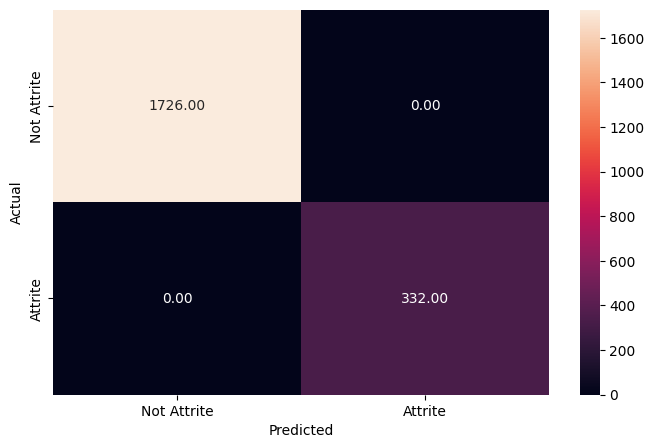

In [47]:
# #Checking performance on the training data
y_pred_train_rf_tuned = rf_estimator_tuned.predict(X_train)
metrics_score(y_train, y_pred_train_rf_tuned)

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       740
           1       0.87      0.80      0.83       142

    accuracy                           0.95       882
   macro avg       0.92      0.89      0.90       882
weighted avg       0.95      0.95      0.95       882



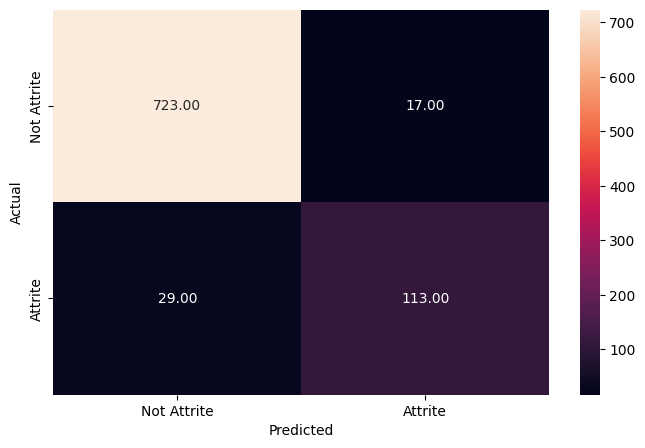

In [48]:
# #Checking performance on the test data
y_pred_test_rf_tuned = rf_estimator_tuned.predict(X_test)
metrics_score(y_test, y_pred_test_rf_tuned)

**Observations:**
-   
-    
-   
